# IRFZ44N MOSFET Analytical Loss Calculation

This notebook estimates the conduction loss, switching loss and total
average power loss of the IRFZ44N MOSFET used in the buck converter.

The analytical result will later be compared with the average MOSFET
power obtained from LTspice.

In [1]:
# Buck converter operating conditions

Vin = 24.0          # Input voltage, V
Vout = 12.0         # Output voltage, V
Iout = 10.0         # Output current, A
fsw = 50_000        # Switching frequency, Hz
Vgs = 10.0          # Gate-source drive voltage, V

D = Vout / Vin      # Ideal buck-converter duty ratio

print(f"Duty ratio = {D:.3f}")

Duty ratio = 0.500


## MOSFET parameters

**MOSFET On-Resistance Cases**

Two on-resistance values are considered in the analytical calculation.

- **0.0139 ohm** is used as the LTspice-model baseline value. This case provides the most consistent comparison with the LTspice average power result.
- **0.0175 ohm** is the maximum datasheet on-resistance specified at 25°C. This case provides a more conservative analytical estimate.

Changing Rds(on) affects the conduction loss only. The switching loss remains unchanged because the switching-loss equation depends on voltage, current, switching times and switching frequency rather than on-resistance.

The rise and fall times are taken from the manufacturer datasheet and
are used to estimate switching loss.

In [2]:
# IRFZ44N MOSFET parameters

Rds_on_model = 0.0139      # LTspice-model baseline resistance, ohms
Rds_on_datasheet = 0.0175  # Datasheet maximum at 25°C, ohms

tr = 60e-9                 # Datasheet rise time, seconds
tf = 45e-9                 # Datasheet fall time, seconds

In [3]:
import math
import pandas as pd

# MOSFET RMS current
I_mosfet_rms = Iout * math.sqrt(D)

# Conduction loss for both resistance values
P_cond_model = I_mosfet_rms**2 * Rds_on_model
P_cond_datasheet = I_mosfet_rms**2 * Rds_on_datasheet

# Switching loss is unchanged by Rds(on)
P_sw = 0.5 * Vin * Iout * (tr + tf) * fsw

# Total losses
P_total_model = P_cond_model + P_sw
P_total_datasheet = P_cond_datasheet + P_sw

results = pd.DataFrame({
    "Case": [
        "LTspice-model resistance",
        "Datasheet maximum resistance"
    ],
    "Rds(on) (ohm)": [
        Rds_on_model,
        Rds_on_datasheet
    ],
    "Conduction loss (W)": [
        P_cond_model,
        P_cond_datasheet
    ],
    "Switching loss (W)": [
        P_sw,
        P_sw
    ],
    "Total analytical loss (W)": [
        P_total_model,
        P_total_datasheet
    ]
})

results.round(3)

,Case,Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total analytical loss (W)
0,LTspice-model resistance,0.014,0.695,0.63,1.325
1,Datasheet maximum resistance,0.018,0.875,0.63,1.505


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv(
    "Exported_vds_Id_4ms_5ms.txt",
    sep=r"\s+",
    engine="python"
)

print(data.head())
print(data.columns)

           time    V(Vin,Vsw)        Id(M1)
0  0.000000e+00  0.000000e+00  1.253150e-09
1  2.000000e-14  5.417492e-09  1.856440e-06
2  4.000000e-14  1.088395e-08  3.706178e-06
3  8.000000e-14  2.191459e-08  7.392287e-06
4  1.600000e-13  4.455971e-08  1.468470e-05
Index(['time', 'V(Vin,Vsw)', 'Id(M1)'], dtype='str')


In [6]:
print(data["time"].min())
print(data["time"].max())

0.0
0.002439581050307561


In [7]:
# Use the final 1 ms of the exported waveform
end_time = data["time"].max()
start_time = end_time - 0.001

steady_state = data[
    (data["time"] >= start_time) &
    (data["time"] <= end_time)
].copy()

print(f"Start time: {start_time * 1000:.3f} ms")
print(f"End time: {end_time * 1000:.3f} ms")
print(f"Number of points: {len(steady_state)}")

Start time: 1.440 ms
End time: 2.440 ms
Number of points: 501861


In [8]:
# Convert the steady-state columns to numeric values
steady_state["time"] = pd.to_numeric(
    steady_state["time"],
    errors="coerce"
)

steady_state["V(Vin,Vsw)"] = pd.to_numeric(
    steady_state["V(Vin,Vsw)"],
    errors="coerce"
)

steady_state["Id(M1)"] = pd.to_numeric(
    steady_state["Id(M1)"],
    errors="coerce"
)

# Remove any rows that could not be converted
steady_state = steady_state.dropna(
    subset=["time", "V(Vin,Vsw)", "Id(M1)"]
).copy()

time = steady_state["time"].to_numpy(dtype=float)
vds = steady_state["V(Vin,Vsw)"].to_numpy(dtype=float)
ids = steady_state["Id(M1)"].to_numpy(dtype=float)

# Instantaneous MOSFET power
power = vds * ids

# Average MOSFET power
average_power = np.trapezoid(power, time) / (
    time[-1] - time[0]
)

print(f"Number of valid points = {len(time)}")
print(f"Average MOSFET power from exported data (used Rds(on)=0.0139) = {average_power:.4f} W")

Number of valid points = 501860
Average MOSFET power from exported data (used Rds(on)=0.0139) = 0.7308 W


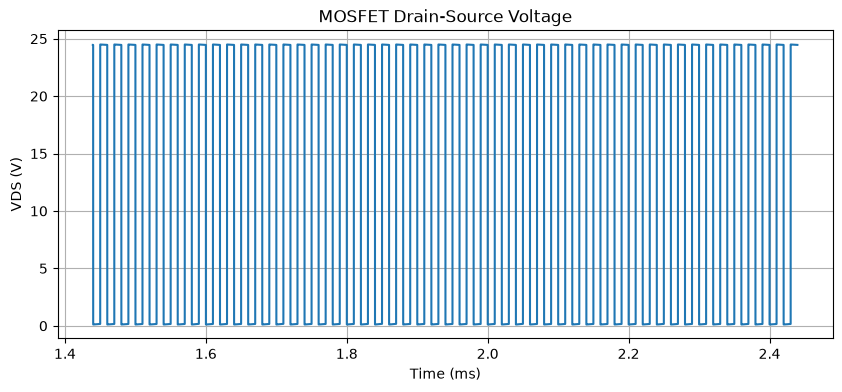

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, vds)
plt.xlabel("Time (ms)")
plt.ylabel("VDS (V)")
plt.title("MOSFET Drain-Source Voltage")
plt.grid()
plt.show()

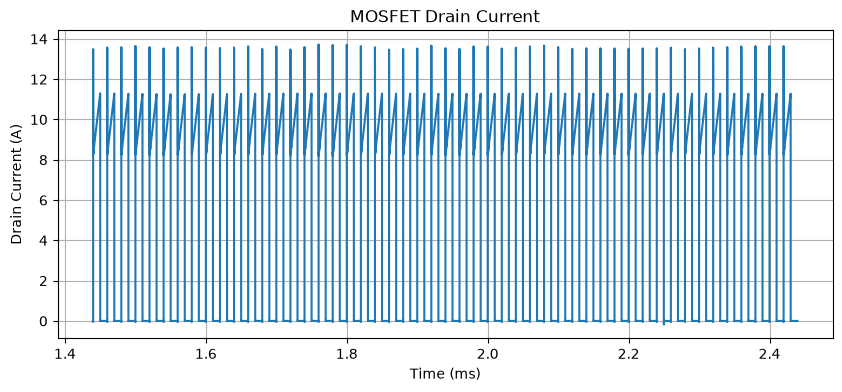

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, ids)
plt.xlabel("Time (ms)")
plt.ylabel("Drain Current (A)")
plt.title("MOSFET Drain Current")
plt.grid()
plt.show()

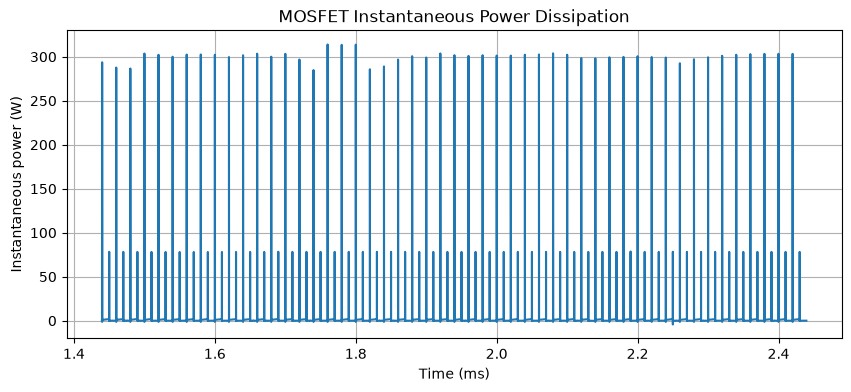

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, power)

plt.xlabel("Time (ms)")
plt.ylabel("Instantaneous power (W)")
plt.title("MOSFET Instantaneous Power Dissipation")
plt.grid()

plt.show()

## Comparison with LTspice

The direct analytical-to-LTspice comparison uses **Rds(on) = 0.0139 ohm**, matching the baseline resistance associated with the LTspice model.

Using this value gives an analytical total MOSFET loss of **1.325 W**, which is compared with the LTspice average power loss of **0.7308 W**.

The separate **0.0175 ohm datasheet maximum case** is treated as a conservative calculation and is not used in this direct comparison.

In [12]:
# Direct comparison using the LTspice-model baseline Rds(on)
Rds_on_comparison = 0.0139

analytical_power_model_case = 1.325
ltspice_power = 0.7308

difference = analytical_power_model_case - ltspice_power

percentage_difference = (
    abs(difference) / analytical_power_model_case * 100
)

print(f"Rds(on) used for analytical comparison = {Rds_on_comparison:.4f} ohm")
print(f"Analytical power loss using 0.0139 ohm = {analytical_power_model_case:.3f} W")
print(f"LTspice average power loss = {ltspice_power:.3f} W")
print(f"Difference = {abs(difference):.3f} W")
print(f"Percentage difference = {percentage_difference:.1f}%")

Rds(on) used for analytical comparison = 0.0139 ohm
Analytical power loss using 0.0139 ohm = 1.325 W
LTspice average power loss = 0.731 W
Difference = 0.594 W
Percentage difference = 44.8%


## Conclusion

Using the **LTspice-model baseline resistance of 0.0139 ohm**, the analytical calculation predicted a total average MOSFET power loss of **1.325 W**, consisting of **0.695 W conduction loss** and **0.630 W switching loss**.

The average power calculated from the exported LTspice voltage and current waveforms was **0.7308 W**, which closely agrees with the direct LTspice measurement of approximately **0.7311 W**. This confirms that the waveform export and numerical integration were performed correctly.

For the 0.0139 ohm comparison case, the analytical result was approximately **44.8% higher** than the LTspice result. This difference is mainly caused by the simplified switching-loss equation, which assumes linear overlap between drain-source voltage and drain current over the full datasheet rise and fall times. The actual simulated switching transitions may be faster under the ideal LTspice gate-drive conditions.

A separate conservative case used the datasheet maximum on-resistance of **0.0175 ohm at 25°C**, producing a higher analytical total loss of **1.505 W**. This value is more suitable as a conservative heat-generation estimate, while the **1.325 W case is retained for direct comparison with the LTspice baseline model**.

Therefore, the **0.731 W LTspice result is reasonable for the simulated circuit**. The analytical results provide more conservative estimates, with **1.325 W representing the model-based comparison case** and **1.505 W representing the datasheet maximum-resistance case**.

## MOSFET Loss at Three Load Points

The three-load-point analytical comparison uses **Rds(on) = 0.0139 ohm**, matching the LTspice-model baseline. The datasheet maximum value of **0.0175 ohm at 25°C** is considered separately in the conservative temperature-dependent analysis.

In [13]:
import pandas as pd

# Fixed converter and MOSFET parameters
Vds = 24
Rds_on_model = 0.0139
duty_cycle = 0.5
rise_time = 60e-9
fall_time = 45e-9
switching_frequency = 50e3

# Three load currents
load_currents = [5, 10, 15]

results = []

for current in load_currents:
    conduction_loss = current**2 * Rds_on_model * duty_cycle

    switching_loss = (
        0.5
        * Vds
        * current
        * (rise_time + fall_time)
        * switching_frequency
    )

    total_loss = conduction_loss + switching_loss

    results.append({
        "Load current (A)": current,
        "Conduction loss (W)": conduction_loss,
        "Switching loss (W)": switching_loss,
        "Analytical total loss (W)": total_loss
    })

analytical_results = pd.DataFrame(results)

analytical_results

,Load current (A),Conduction loss (W),Switching loss (W),Analytical total loss (W)
0,5,0.17375,0.315,0.48875
1,10,0.69500,0.630,1.32500
2,15,1.56375,0.945,2.50875


In [14]:

ltspice_losses = [
    0.221,   # 5 A result
    0.731,   # 10 A result
    1.589    # 15 A result
]

analytical_results["LTspice loss (W)"] = ltspice_losses

analytical_results["Difference (W)"] = (
    analytical_results["Analytical total loss (W)"]
    - analytical_results["LTspice loss (W)"]
)

analytical_results["Difference (%)"] = (
    analytical_results["Difference (W)"]
    / analytical_results["Analytical total loss (W)"]
    * 100
)

analytical_results.round(3)

,Load current (A),Conduction loss (W),Switching loss (W),Analytical total loss (W),LTspice loss (W),Difference (W),Difference (%)
0,5,0.174,0.315,0.489,0.221,0.268,54.783
1,10,0.695,0.630,1.325,0.731,0.594,44.830
2,15,1.564,0.945,2.509,1.589,0.920,36.662


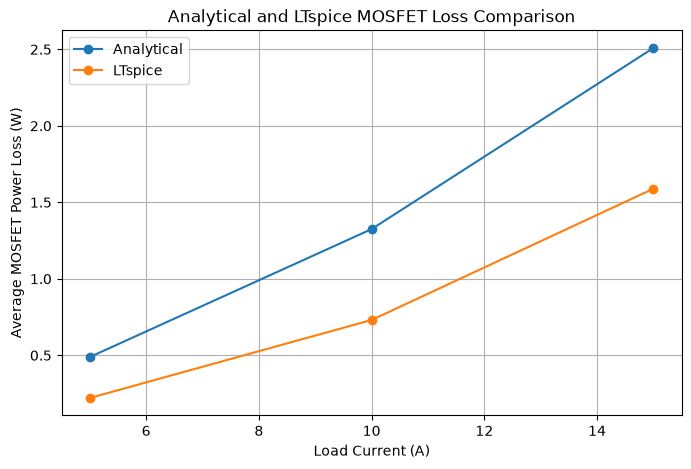

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    analytical_results["Load current (A)"],
    analytical_results["Analytical total loss (W)"],
    marker="o",
    label="Analytical"
)

plt.plot(
    analytical_results["Load current (A)"],
    analytical_results["LTspice loss (W)"],
    marker="o",
    label="LTspice"
)

plt.xlabel("Load Current (A)")
plt.ylabel("Average MOSFET Power Loss (W)")
plt.title("Analytical and LTspice MOSFET Loss Comparison")
plt.grid()
plt.legend()
plt.show()

## Conclusion

The MOSFET loss was evaluated at load currents of **5 A, 10 A and 15 A** using analytical calculations and LTspice. The analytical comparison used the LTspice-model baseline resistance of **0.0139 ohm**.

An acceptance limit of 10% was selected. Since all three load-point differences exceed this limit, the disagreement was investigated and documented.

Both methods showed that MOSFET power loss increased as load current increased. This occurs because conduction loss increases approximately with the square of current, while switching loss increases approximately in proportion to current.

The analytical calculation predicted higher losses than LTspice at all three load points. The percentage difference decreased from approximately **54.8% at 5 A** to **36.7% at 15 A**. The difference is mainly caused by the simplified analytical switching-loss equation, which assumes linear voltage-current overlap over the full datasheet rise and fall times. LTspice instead calculates power directly from the simulated voltage and current waveforms.

The results confirm that load current has a significant effect on MOSFET heat generation, particularly at the high-load operating point.

## Temperature-Dependent MOSFET On-Resistance

The IRFZ44N on-resistance increases as junction temperature rises. The datasheet maximum on-resistance of **0.0175 ohm at 25°C** is used as the reference value.

The resistance at another temperature is estimated using:

`Rds_on(T) = Rds_on(25°C) × normalised resistance factor`

The normalised factors are approximate values read from Figure 4 of the IRFZ44N datasheet. Therefore, this is a datasheet-based engineering estimate rather than an exact manufacturer table.

The earlier value of **0.0139 ohm** is retained only for the direct analytical comparison with the LTspice baseline model.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datasheet maximum Rds(on) at 25°C
rds_on_25 = 0.0175

# Approximate values read from the datasheet normalised curve
temperatures = np.array([25, 50, 75, 100, 125, 150])

normalised_factors = np.array([
    1.00,
    1.15,
    1.35,
    1.58,
    1.82,
    2.10,
])

temperature_results = pd.DataFrame({
    "Junction temperature (°C)": temperatures,
    "Normalised Rds(on)": normalised_factors
})

temperature_results["Rds(on) (ohm)"] = (
    rds_on_25 * temperature_results["Normalised Rds(on)"]
)

temperature_results.round(5)

,Junction temperature (°C),Normalised Rds(on),Rds(on) (ohm)
0,25,1.00,0.01750
1,50,1.15,0.02012
2,75,1.35,0.02363
3,100,1.58,0.02765
4,125,1.82,0.03185
5,150,2.10,0.03675


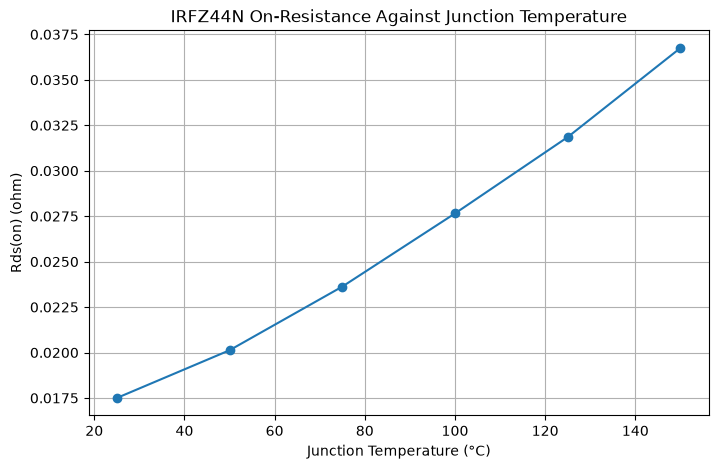

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    temperature_results["Junction temperature (°C)"],
    temperature_results["Rds(on) (ohm)"],
    marker="o"
)

plt.xlabel("Junction Temperature (°C)")
plt.ylabel("Rds(on) (ohm)")
plt.title("IRFZ44N On-Resistance Against Junction Temperature")
plt.grid()

plt.show()

In [18]:
current = 10.0
duty_cycle = 0.5

temperature_results["Conduction loss (W)"] = (
    current**2
    * temperature_results["Rds(on) (ohm)"]
    * duty_cycle
)

temperature_results.round(4)

,Junction temperature (°C),Normalised Rds(on),Rds(on) (ohm),Conduction loss (W)
0,25,1.00,0.0175,0.8750
1,50,1.15,0.0201,1.0062
2,75,1.35,0.0236,1.1813
3,100,1.58,0.0277,1.3825
4,125,1.82,0.0319,1.5925
5,150,2.10,0.0368,1.8375


In [19]:
switching_loss = 0.630

temperature_results["Switching loss (W)"] = switching_loss

temperature_results["Total analytical loss (W)"] = (
    temperature_results["Conduction loss (W)"]
    + temperature_results["Switching loss (W)"]
)

temperature_results.round(4)

,Junction temperature (°C),Normalised Rds(on),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total analytical loss (W)
0,25,1.00,0.0175,0.8750,0.63,1.5050
1,50,1.15,0.0201,1.0062,0.63,1.6362
2,75,1.35,0.0236,1.1813,0.63,1.8113
3,100,1.58,0.0277,1.3825,0.63,2.0125
4,125,1.82,0.0319,1.5925,0.63,2.2225
5,150,2.10,0.0368,1.8375,0.63,2.4675


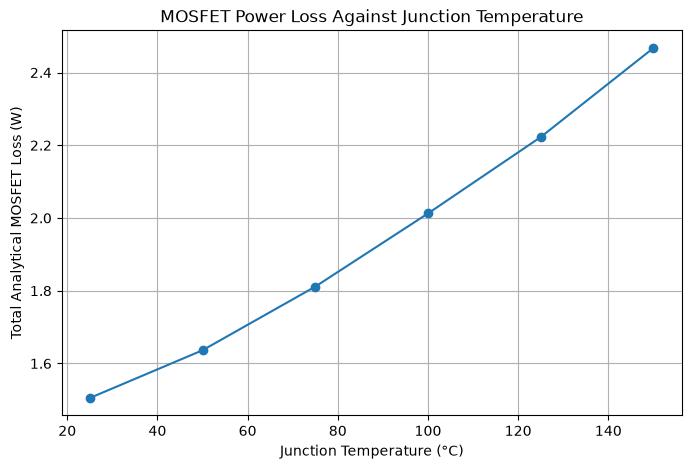

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    temperature_results["Junction temperature (°C)"],
    temperature_results["Total analytical loss (W)"],
    marker="o"
)

plt.xlabel("Junction Temperature (°C)")
plt.ylabel("Total Analytical MOSFET Loss (W)")
plt.title("MOSFET Power Loss Against Junction Temperature")
plt.grid()

plt.show()

### Temperature-Dependence Conclusion

The datasheet-based calculation shows that the IRFZ44N on-resistance increases significantly with junction temperature. Using the datasheet maximum value of **0.0175 ohm at 25°C**, the estimated resistance increases to approximately **0.042 ohm at 175°C**.

At the 10 A baseline operating point, this increases the estimated conduction loss from approximately **0.875 W at 25°C** to approximately **2.100 W at 175°C**. Under the simplified assumption that switching loss remains constant at **0.630 W**, the total analytical MOSFET loss increases from approximately **1.505 W to 2.730 W**.

This demonstrates positive electrical-thermal feedback: a higher junction temperature increases Rds(on), which increases conduction loss and produces additional heat.

## Electrical Loss CSV Export

A CSV file is created containing the three operating points, analytical conduction loss, analytical switching loss, analytical total loss, LTspice average loss and the assumed junction temperature.

The junction temperature is initially assumed to be 25°C. It will later be updated using results from the thermal model and electro-thermal coupling.

In [23]:
# Create the electrical loss table

electrical_loss_table = analytical_results[
    [
        "Load current (A)",
        "Conduction loss (W)",
        "Switching loss (W)",
        "Analytical total loss (W)",
        "LTspice loss (W)"
    ]
].copy()

# Add case names
electrical_loss_table.insert(
    0,
    "Case",
    ["Low load", "Baseline", "High load"]
)

# Add fixed operating-point information
electrical_loss_table.insert(1, "Input voltage (V)", 24.0)
electrical_loss_table.insert(2, "Output voltage (V)", 12.0)
electrical_loss_table.insert(3, "Switching frequency (Hz)", 50000)
electrical_loss_table.insert(4, "Duty cycle", 0.5)

# Resistance used for the direct analytical-to-LTspice comparison
electrical_loss_table["Rds(on) used (ohm)"] = 0.0139

# Initial assumed junction temperature
electrical_loss_table["Assumed junction temperature (°C)"] = 25.0

electrical_loss_table.round(4)

,Case,Input voltage (V),Output voltage (V),Switching frequency (Hz),Duty cycle,Load current (A),Conduction loss (W),Switching loss (W),Analytical total loss (W),LTspice loss (W),Rds(on) used (ohm),Assumed junction temperature (°C)
0,Low load,24.0,12.0,50000,0.5,5,0.1737,0.315,0.4888,0.221,0.0139,25.0
1,Baseline,24.0,12.0,50000,0.5,10,0.6950,0.630,1.3250,0.731,0.0139,25.0
2,High load,24.0,12.0,50000,0.5,15,1.5638,0.945,2.5088,1.589,0.0139,25.0


In [24]:
output_path = "../../data/electrical_loss_table.csv"

electrical_loss_table.to_csv(
    output_path,
    index=False
)

print(f"CSV saved to: {output_path}")

CSV saved to: ../../data/electrical_loss_table.csv


Baseline operating point: 10 A

Baseline conservative heat input: 1.505 W

Ambient temperature: 25°C